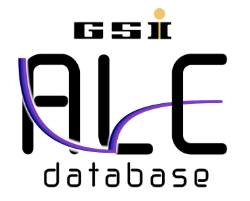

# GSI ALC Database Demo

Welcome to the **GSI ALC Database Demo-script**! This notebook is designed to demonstrate how you can interact with and explore the **Absolute Lymphocyte Count (ALC) database** developed at GSI. 

Please note that this is not a rigorous scientific analysis. Instead, it serves as a practical demo with sample code to show how you can "play" with this database and extract useful insights.


### Step 0: Import Required Libraries

Before we start, we need to import some essential Python libraries that will help us manipulate the data and visualize it.

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import ast
import re
import os

### Step 1: Load the Dataset

We will now read the main dataset (`datasets_table.xlsx`) into a DataFrame using `pandas`. This dataset contains information about multiple publications and related data points.

In [2]:
data = pd.read_excel("datasets_table.xlsx", dtype={'Dataset specification': str, 'Comments': str})

# Ensure '# of patients' is numeric
data['# Patients'] = pd.to_numeric(data['# Patients'], errors='coerce')
data['# Datapoints'] = pd.to_numeric(data['# Datapoints'], errors='coerce')
data['Estimated RLC at EoT (%)'] = pd.to_numeric(data['Estimated RLC at EoT (%)'], errors='coerce')
data['Radiation type'] = data['Radiation type'].apply(
    lambda x: [item.strip() for item in str(x).split(',')] if pd.notna(x) else []
)
data['Derived datasets'] = data['Derived datasets'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
data['Estimated EoT Time (wk)'] = data['Estimated EoT Time (wk)'].astype(str).str.replace('*', '', regex=False).astype(float)
data['Therapy modality'] = data['Therapy modality'].astype(str).str.replace('*', '', regex=False)

#to show first 5 entries of the data
data.head(5)

,Dataset ID,Publication tag,Site classification,Irradiated organ,Treatment indication,Radiation type,Therapy modality,# Patients,# Datapoints,Has recovery data,...,Combined dataset,Derived datasets,Estimated EoT Time (wk),Estimated RLC at EoT (%),DOI,Comments,Dataset specification,Relative path,Main author,Year
0,1,Balmanoukian12,Digestive/Gastrointestinal,Pancreas,Resected pancreatic adenocarcinoma,[g],CRT,53.0,17,True,...,False,NaN,5.6,37.6,https://doi.org/10.3109/07357907.2012.700987,NaN,NaN,Balmanoukian_2012/data/Balmanoukian_2012.dat,Balmanoukian,2012
1,3,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",460.0,13,True,...,False,2,5.0,28.9,https://doi.org/10.1007/s00066-019-01462-5,Could be overlapping with Park19,OS >= 15.8 months,Byun_2019/data/Byun_2019_HighOS.dat,Byun,2019
2,4,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",460.0,13,True,...,False,2,5.0,28.2,https://doi.org/10.1007/s00066-019-01462-5,Could be overlapping with Park19,OS < 15.8 months,Byun_2019/data/Byun_2019_LowOS.dat,Byun,2019
3,2,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",920.0,13,True,...,True,"(3, 4)",5.0,27.3,https://doi.org/10.1007/s00066-019-01462-5,Could be overlapping with Park19,All patients together,Byun_2019/data/Byun_2019_AllPatients.dat,Byun,2019
4,6,Campian13,Respiratory/Thoracic,Lung,Non-small cell lung cancer,[g],CRT,20.0,7,True,...,False,NaN,6.0,31.3,https://doi.org/10.3109/07357907.2013.767342,NaN,Neoadjuvant chemotherapy + CCRT,Campian_2013/data/Campian_2013_Neoadj+ConcChem...,Campian,2013


### Let's make some statistics on the entries in the data

In [3]:
# Count key statistics
n_datasets = data.shape[0]
n_papers = data['Publication tag'].nunique()
n_dois = data['DOI'].nunique()
n_has_recovery = data['Has recovery data'].sum()
n_normalized = data['Normalized'].sum()
n_pooled_datasets = data['Combined dataset'].sum()
n_papers_with_pooled_data = data[data['Combined dataset']]['Publication tag'].nunique()

# Derived datasets
n_parent_datasets = data['Derived datasets'].apply(lambda x: isinstance(x, tuple)).sum()
n_daughter_datasets = data['Derived datasets'].apply(lambda x: isinstance(x, int)).sum()
n_papers_with_parents = data[data['Derived datasets'].apply(lambda x: isinstance(x, tuple))]['Publication tag'].nunique()
n_papers_with_daughters = data[data['Derived datasets'].apply(lambda x: isinstance(x, int))]['Publication tag'].nunique()

# Individual and undefined datasets
n_individ_datasets = data['# Patients'].eq(1).sum()
n_individ_papers = data[data['# Patients'] == 1]['Publication tag'].nunique()
n_undefined_datasets = data['Estimated EoT Time (wk)'].apply(lambda x: isinstance(x, tuple)).sum()
n_undefined_papers = data[data['Estimated EoT Time (wk)'].apply(lambda x: isinstance(x, tuple))]['Publication tag'].nunique()

# Undefined values
undefined_counts = {
    'Estimated EoT Time': data['Estimated EoT Time (wk)'].isna().sum(),
    '# Patients': data['# Patients'].isna().sum()
}

# Recovery and normalized data stats
n_papers_with_recovery = data[data['Has recovery data']]['Publication tag'].nunique()
n_papers_with_normalized = data[data['Normalized']]['Publication tag'].nunique()

# Print results in a formatted, readable way
results = f"""
Number of datasets (papers): {n_datasets} ({n_papers})
Number of unique DOIs: {n_dois} — DOIs match papers: {n_papers == n_dois}
Datasets (papers) with recovery data: {n_has_recovery} ({n_papers_with_recovery})
Datasets (papers) with normalized data: {n_normalized} ({n_papers_with_normalized})
Pooled datasets (papers): {n_pooled_datasets} ({n_papers_with_pooled_data})
Parent datasets (papers): {n_parent_datasets} ({n_papers_with_parents})
Daughter datasets (papers): {n_daughter_datasets} ({n_papers_with_daughters})
Datasets (papers) on individuals: {n_individ_datasets} ({n_individ_papers})
Datasets (papers) with undefined therapy duration: {n_undefined_datasets} ({n_undefined_papers})
Undefined 'Estimated EoT Time': {undefined_counts['Estimated EoT Time']}
Undefined '# Patients': {undefined_counts['# Patients']}
"""
print(results)



Number of datasets (papers): 142 (52)
Number of unique DOIs: 52 — DOIs match papers: True
Datasets (papers) with recovery data: 66 (34)
Datasets (papers) with normalized data: 30 (7)
Pooled datasets (papers): 10 (9)
Parent datasets (papers): 10 (9)
Daughter datasets (papers): 27 (9)
Datasets (papers) on individuals: 57 (7)
Datasets (papers) with undefined therapy duration: 0 (0)
Undefined 'Estimated EoT Time': 0
Undefined '# Patients': 8



#### Let's look at datasets with undefined EoT-time and number of patients

In [4]:
# Check for undefined values (empty, NaN, etc.) in 'Estimated EoT Time (wk)'
undefined_datasets_list = data[data['Estimated EoT Time (wk)'].isna()]
undefined_patients_list = data[data['# Patients'].isna()]

# Display the list of datasets with undefined 'Estimated Therapy Duration (wk)'
print("Datasets with Undefined Estimated Therapy Duration:")
print(undefined_datasets_list['Publication tag'])

print('\n-=-=-=-=-=-=-=-=-=-=-=-=-=-\n')
# Display the list of datasets with undefined '# of patients'
print("Datasets with Undefined Number of Patients:")
print(undefined_patients_list['Publication tag'])


Datasets with Undefined Estimated Therapy Duration:
Series([], Name: Publication tag, dtype: object)

-=-=-=-=-=-=-=-=-=-=-=-=-=-

Datasets with Undefined Number of Patients:
93     Liu18
94     Liu18
95     Liu18
96     Liu18
97     Liu18
98     Liu18
99     Liu18
100    Liu18
Name: Publication tag, dtype: object


### Let's look at the number of papers and datasets for particular irradiated organs

In [5]:
# Count the number of unique papers (Publication tag) and datasets for each Irradiated site
site_summary = data.groupby('Irradiated organ').agg(
    num_papers=('Publication tag', 'nunique'),
    num_datasets=('Dataset ID', 'count')
).reset_index()

# Display the result
print(site_summary)

                                    Irradiated organ  num_papers  num_datasets
0                                               Anal           1             1
1                                              Blood           5            19
2                             Bones in various sites           1             1
3                                              Brain           5             8
4                                             Breast           2             2
5                                             Cervix           2             2
6                                          Esophagus          13            47
7                                          Head/Neck           4            16
8    Iliacal and paraaortic lymph nodes, Mediastinum           1             1
9                                              Liver           3             5
10                                              Lung           5             8
11                                          Pancreas

### Step 2: Display and Plot Basic Statistics

In this section, we calculate and display basic statistics for several key columns in the dataset:
- **Number of Patients**
- **Number of Datapoints**
- **Estimated Therapy Duration (in weeks)**
- **Estimated Relative Lymphocyte Count (RLC) at End of Therapy (EoT)**

For each variable, we will:
1. Calculate the **mean**, **median**, and **range**.
2. Plot a histogram to visualize the distribution of values.



-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

Number of Patients Statistics:
Mean: 98.72
Median: 21.00
Range: 1.0 - 920.0


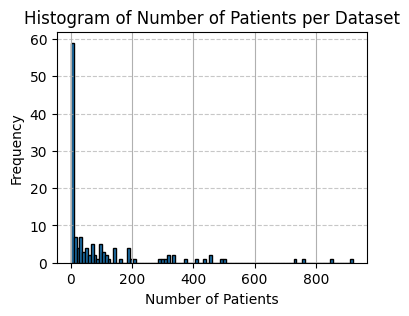


-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

Number of Patients (excluding individual datasets) Statistics:
Mean: 171.05
Median: 95.00
Range: 4.0 - 920.0


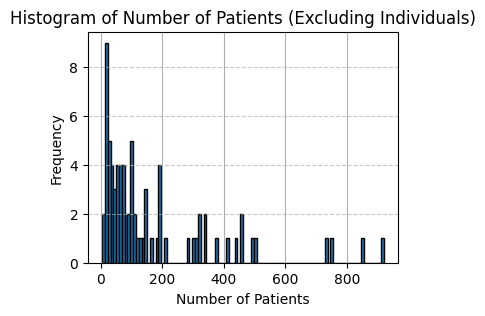


-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

Number of Datapoints Statistics:
Mean: 11.69
Median: 7.00
Range: 3 - 81


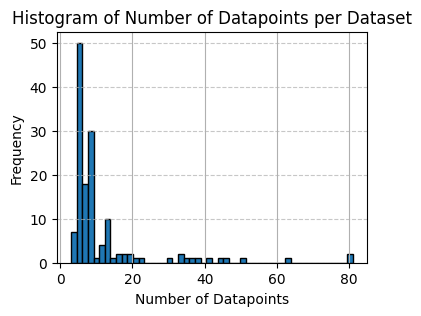


-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

Estimated Therapy Duration (weeks) Statistics:
Mean: 5.61
Median: 5.60
Range: 0.57 - 15.0


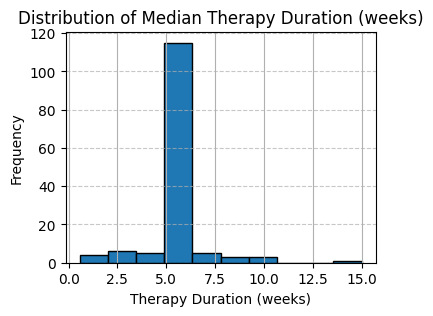


-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

Estimated RLC at EoT (%) Statistics:
Mean: 27.52
Median: 22.80
Range: 0.9 - 78.3


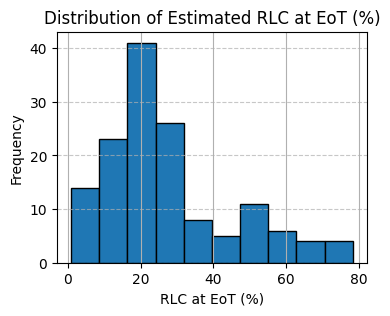

In [6]:
# Function to display basic statistics
def display_statistics(title, mean, median, value_range):
    print("\n-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-\n")
    print(f"{title} Statistics:")
    print(f"Mean: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Range: {value_range[0]} - {value_range[1]}")

# Function to plot histograms
def plot_histogram(data, title, xlabel, bins=20):
    plt.figure(figsize=(4, 3))
    data.hist(bins=bins, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Section 1: Number of Patients
mean_patients = data['# Patients'].mean()
median_patients = data['# Patients'].median()
range_patients = (data['# Patients'].min(), data['# Patients'].max())

display_statistics("Number of Patients", mean_patients, median_patients, range_patients)
plot_histogram(data['# Patients'], "Histogram of Number of Patients per Dataset", "Number of Patients", bins=100)

mean_patients_no_individ = data['# Patients'][data['# Patients'] > 1].mean()
median_patients_no_individ = data['# Patients'][data['# Patients'] > 1].median()
range_patients_no_individ = (data['# Patients'][data['# Patients'] > 1].min(), data['# Patients'].max())

display_statistics("Number of Patients (excluding individual datasets)", mean_patients_no_individ, median_patients_no_individ, range_patients_no_individ)
plot_histogram(data['# Patients'][data['# Patients'] > 1], "Histogram of Number of Patients (Excluding Individuals)", "Number of Patients", bins=100)

# Section 2: Number of Datapoints
mean_datapoints = data['# Datapoints'].mean()
median_datapoints = data['# Datapoints'].median()
range_datapoints = (data['# Datapoints'].min(), data['# Datapoints'].max())

display_statistics("Number of Datapoints", mean_datapoints, median_datapoints, range_datapoints)
plot_histogram(data['# Datapoints'], "Histogram of Number of Datapoints per Dataset", "Number of Datapoints", bins=50)

# Section 3: Estimated Therapy Duration
mean_duration = data['Estimated EoT Time (wk)'].mean()
median_duration = data['Estimated EoT Time (wk)'].median()
range_duration = (data['Estimated EoT Time (wk)'].min(), data['Estimated EoT Time (wk)'].max())

display_statistics("Estimated Therapy Duration (weeks)", mean_duration, median_duration, range_duration)
plot_histogram(data['Estimated EoT Time (wk)'].dropna(), "Distribution of Median Therapy Duration (weeks)", "Therapy Duration (weeks)", bins=10)

# Section 4: Estimated RLC at EoT (%)
mean_nadir = data['Estimated RLC at EoT (%)'].mean()
median_nadir = data['Estimated RLC at EoT (%)'].median()
range_nadir = (data['Estimated RLC at EoT (%)'].min(), data['Estimated RLC at EoT (%)'].max())

display_statistics("Estimated RLC at EoT (%)", mean_nadir, median_nadir, range_nadir)
plot_histogram(data['Estimated RLC at EoT (%)'].dropna(), "Distribution of Estimated RLC at EoT (%)", "RLC at EoT (%)", bins=10)


### Step 3: Load Data from File Paths

In this step, we will read data from the files specified in the `Relative path` column and populate the corresponding cells in the DataFrame.

Each file contains measurements of `x`, `y`, `x_low_err`, `x_high_err`, `y_low_err`, and `y_high_err`. These values will be converted into lists and assigned to the relevant columns.

In [7]:
import pandas as pd

def read_data(file_path):
    """
    Reads data from a file, skipping the header lines and returning a dictionary of lists for each column.

    Parameters:
    - file_path (str): Relative path to the file containing data.

    Returns:
    - dict: Dictionary with keys ['x', 'y', 'x_low_err', 'x_high_err', 'y_low_err', 'y_high_err'] containing lists of values.
    """
    try:
        # Read the file, skipping the header, and parse columns
        df = pd.read_csv(file_path, sep=';', skiprows=8, header=None)
        df.columns = ['x', 'y', 'x_low_err', 'x_high_err', 'y_low_err', 'y_high_err']
        # Convert each column to a list
        return {
            'x': df['x'].tolist(),
            'y': df['y'].tolist(),
            'x_low_err': df['x_low_err'].tolist(),
            'x_high_err': df['x_high_err'].tolist(),
            'y_low_err': df['y_low_err'].tolist(),
            'y_high_err': df['y_high_err'].tolist()
        }
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return {'x': [], 'y': [], 'x_low_err': [], 'x_high_err': [], 'y_low_err': [], 'y_high_err': []}

# Add new columns to store the lists of data points
data['x'] = None
data['y'] = None
data['x_low_err'] = None
data['x_high_err'] = None
data['y_low_err'] = None
data['y_high_err'] = None



# Get current working directory
current_folder = os.getcwd()
#print(f"Current folder: {current_folder}")


# Iterate over each row and populate the new columns with lists from corresponding data files
for index, row in data.iterrows():
    file_path = row['Relative path']
    file_data = read_data(current_folder+'/'+file_path)  # Read the data from the file
    # Add lists to the corresponding columns
    data.at[index, 'x'] = file_data['x']
    data.at[index, 'y'] = file_data['y']
    data.at[index, 'x_low_err'] = file_data['x_low_err']
    data.at[index, 'x_high_err'] = file_data['x_high_err']
    data.at[index, 'y_low_err'] = file_data['y_low_err']
    data.at[index, 'y_high_err'] = file_data['y_high_err']

# Display the updated DataFrame
data.head()


,Dataset ID,Publication tag,Site classification,Irradiated organ,Treatment indication,Radiation type,Therapy modality,# Patients,# Datapoints,Has recovery data,...,Dataset specification,Relative path,Main author,Year,x,y,x_low_err,x_high_err,y_low_err,y_high_err
0,1,Balmanoukian12,Digestive/Gastrointestinal,Pancreas,Resected pancreatic adenocarcinoma,[g],CRT,53.0,17,True,...,NaN,Balmanoukian_2012/data/Balmanoukian_2012.dat,Balmanoukian,2012,"[0.31088, 4.43661, 8.84098, 12.99483, 17.32066...","[1954.12844, 733.94495, 605.50459, 697.24771, ...","[0.31088, 4.43661, 8.84098, 12.99483, 17.32066...","[0.31088, 4.43661, 8.84098, 12.99483, 17.32066...","[1080.733946, 233.027526, 207.339452, 273.3944...","[2519.266062, 1594.49541, 1401.834866, 1249.54..."
1,3,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",460.0,13,True,...,OS >= 15.8 months,Byun_2019/data/Byun_2019_HighOS.dat,Byun,2019,"[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[1248.96266, 360.99585, 917.01245, 780.08299, ...","[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[720.331942, 157.676342, 487.136934, 425.72613...","[1771.784232, 709.543574, 1579.253106, 1320.33..."
2,4,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",460.0,13,True,...,OS < 15.8 months,Byun_2019/data/Byun_2019_LowOS.dat,Byun,2019,"[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[987.55187, 278.0083, 742.73859, 572.61411, 53...","[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[633.195014, 138.589216, 376.763484, 334.43983...","[1527.800824, 492.946058, 1457.261406, 880.497..."
3,2,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",920.0,13,True,...,All patients together,Byun_2019/data/Byun_2019_AllPatients.dat,Byun,2019,"[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[1118.71143, 305.60114, 837.1633, 649.5623, 60...","[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[630.21258, 138.784938, 384.382706, 351.691818...","[1696.597634, 597.50548, 1498.427036, 1126.155..."
4,6,Campian13,Respiratory/Thoracic,Lung,Non-small cell lung cancer,[g],CRT,20.0,7,True,...,Neoadjuvant chemotherapy + CCRT,Campian_2013/data/Campian_2013_Neoadj+ConcChem...,Campian,2013,"[0.0, 4.21111, 8.61555, 12.88733, 17.33144, 21...","[1487.28814, 466.10169, 478.81356, 677.9661, 6...","[0.0, 4.21111, 8.61555, 12.88733, 17.33144, 21...","[0.0, 4.21111, 8.61555, 12.88733, 17.33144, 21...","[936.44068, 118.64407, 182.20339, 389.83051, 2...","[2064.417, 787.82273, 788.53764, 969.91741, 10..."


### Processing Error Values

The `x_err` and `y_err` lists represent the positions of the lower and upper error limits. To convert them into actual uncertainty values (error magnitudes), we need to process them as follows:
- `x_err` → `|x - x_err|`
- `y_err` → `|y - y_err|`

In [8]:
for index, row in data.iterrows():
    # Get lists from the row
    x = row['x']
    y = row['y']
    x_low_err = row['x_low_err']
    x_high_err = row['x_high_err']
    y_low_err = row['y_low_err']
    y_high_err = row['y_high_err']
    
    # Check if lists are not empty and have the same length
    if all(isinstance(lst, list) and len(lst) == len(x) for lst in [x, y, x_low_err, x_high_err, y_low_err, y_high_err]):
        # Apply transformations to each element in the lists
        new_x_low_err = [xi - xi_low for xi, xi_low in zip(x, x_low_err)]
        new_x_high_err = [xi_high - xi for xi, xi_high in zip(x, x_high_err)]
        new_y_low_err = [yi - yi_low for yi, yi_low in zip(y, y_low_err)]
        new_y_high_err = [yi_high - yi for yi, yi_high in zip(y, y_high_err)]
        
        # Update the DataFrame with the transformed lists
        data.at[index, 'x_low_err'] = new_x_low_err
        data.at[index, 'x_high_err'] = new_x_high_err
        data.at[index, 'y_low_err'] = new_y_low_err
        data.at[index, 'y_high_err'] = new_y_high_err

# Display the updated DataFrame
data.head()


,Dataset ID,Publication tag,Site classification,Irradiated organ,Treatment indication,Radiation type,Therapy modality,# Patients,# Datapoints,Has recovery data,...,Dataset specification,Relative path,Main author,Year,x,y,x_low_err,x_high_err,y_low_err,y_high_err
0,1,Balmanoukian12,Digestive/Gastrointestinal,Pancreas,Resected pancreatic adenocarcinoma,[g],CRT,53.0,17,True,...,NaN,Balmanoukian_2012/data/Balmanoukian_2012.dat,Balmanoukian,2012,"[0.31088, 4.43661, 8.84098, 12.99483, 17.32066...","[1954.12844, 733.94495, 605.50459, 697.24771, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[873.3944939999999, 500.917424, 398.165138, 42...","[565.1376220000002, 860.55046, 796.33027599999..."
1,3,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",460.0,13,True,...,OS >= 15.8 months,Byun_2019/data/Byun_2019_HighOS.dat,Byun,2019,"[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[1248.96266, 360.99585, 917.01245, 780.08299, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[528.6307179999999, 203.319508, 429.8755159999...","[522.8215720000001, 348.547724, 662.240656, 54..."
2,4,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",460.0,13,True,...,OS < 15.8 months,Byun_2019/data/Byun_2019_LowOS.dat,Byun,2019,"[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[987.55187, 278.0083, 742.73859, 572.61411, 53...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[354.356856, 139.41908400000003, 365.975106000...","[540.2489539999999, 214.93775799999997, 714.52..."
3,2,Byun19,Digestive/Gastrointestinal,Liver,Hepatocellular carcinoma,[g],"CRT, IMRT, SBRT",920.0,13,True,...,All patients together,Byun_2019/data/Byun_2019_AllPatients.dat,Byun,2019,"[0.0, 4.30416, 8.61448, 13.09871, 17.36524, 21...","[1118.71143, 305.60114, 837.1633, 649.5623, 60...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[488.49885000000006, 166.81620199999998, 452.7...","[577.8862039999999, 291.90434000000005, 661.26..."
4,6,Campian13,Respiratory/Thoracic,Lung,Non-small cell lung cancer,[g],CRT,20.0,7,True,...,Neoadjuvant chemotherapy + CCRT,Campian_2013/data/Campian_2013_Neoadj+ConcChem...,Campian,2013,"[0.0, 4.21111, 8.61555, 12.88733, 17.33144, 21...","[1487.28814, 466.10169, 478.81356, 677.9661, 6...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[550.8474600000001, 347.45762, 296.61017, 288....","[577.1288599999998, 321.72103999999996, 309.72..."


### Let's look at some dataset with particular data ID

In [9]:
def print_dataset_by_id(data, dataset_id):
    """
    Prints data for a specific Dataset ID from the DataFrame, formatting numbers to 3 decimal places.
    
    Parameters:
    - data (DataFrame): The DataFrame containing datasets.
    - dataset_id (int): The Dataset ID to filter and print.
    """
    row = data[data['Dataset ID'] == dataset_id]
    
    if not row.empty:
        print(f"\nDataset ID: {row.iloc[0]['Dataset ID']} | Publication tag: {row.iloc[0]['Publication tag']}")
        print(f"Relative path: {row.iloc[0]['Relative path']}")
        
        # Extract relevant columns
        x = row.iloc[0]['x']
        y = row.iloc[0]['y']
        x_low_err = row.iloc[0]['x_low_err']
        x_high_err = row.iloc[0]['x_high_err']
        y_low_err = row.iloc[0]['y_low_err']
        y_high_err = row.iloc[0]['y_high_err']
        
        # Check if lists are not empty
        if all(isinstance(lst, list) for lst in [x, y, x_low_err, x_high_err, y_low_err, y_high_err]):
            print("\n  x       y       x_low_err  x_high_err  y_low_err  y_high_err")
            print("---------------------------------------------------------------")
            for i in range(len(x)):
                print(f"{x[i]:<7.3f} {y[i]:<10.3f} {x_low_err[i]:<9.3f} {x_high_err[i]:<12.3f} {y_low_err[i]:<12.3f} {y_high_err[i]:<11.3f}")
        else:
            print("No data available for this dataset.")
    else:
        print(f"No dataset found with Dataset ID: {dataset_id}")

# Example usage
dataset_id = 123  # Replace with the desired Dataset ID
print_dataset_by_id(data, dataset_id)



Dataset ID: 123 | Publication tag: Sumiya21
Relative path: Sumiya_2021/data/Sumiya_2021_AllPatients_PBT.dat

  x       y       x_low_err  x_high_err  y_low_err  y_high_err
---------------------------------------------------------------
0.000   1418.826   0.000     0.000        75.225       81.438     
1.000   964.437    0.000     0.000        69.672       46.668     
2.000   591.354    0.000     0.000        52.353       34.902     
3.000   456.901    0.000     0.000        40.719       40.587     
4.000   380.487    0.000     0.000        29.085       40.719     
5.000   303.940    0.000     0.000        40.587       17.319     
6.000   326.547    0.000     0.000        69.672       46.668     
10.300  895.955    0.000     0.000        93.205       87.123     
32.100  1203.199   0.000     0.000        406.928      483.078    


### Step 4: Plot Datasets

In this step, we will plot all datasets into a single pad. Error bars and datasets from Chanana et al., 1976 and Weeke et al., 1970, were omitted for better picture.

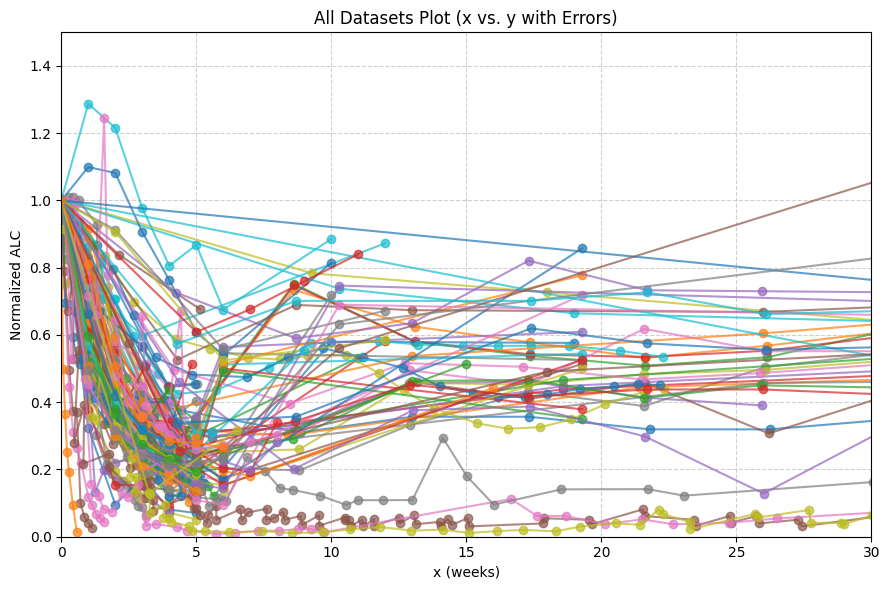

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Plot all datasets together
plt.figure(figsize=(9, 6))
for index, row in data.iterrows():
    # Convert data to numpy arrays
    x = np.array(row['x'])
    y = np.array(row['y'])
    x_low_err = np.array(row['x_low_err'])
    x_high_err = np.array(row['x_high_err'])
    y_low_err = np.array(row['y_low_err'])
    y_high_err = np.array(row['y_high_err'])
    
    # Check if y[0] is not zero to avoid division by zero
    if y[0] != 0:
        y_low_err = y_low_err / y[0]
        y_high_err = y_high_err / y[0]
        y = y / y[0]

        
        if row['Publication tag'] == 'Chanana76': #filter this very fluctuative data
            continue
        if row['Publication tag'] == 'Weeke70': #filter this data with dose on x - axis
            continue
    
        # Convert errors into arrays for plotting (absolute errors)
        x_err = [x_low_err, x_high_err ]
        y_err = [y_low_err, y_high_err ]
        
        # Plot with error bars
        plt.errorbar(x, y, label=f"Dataset ID: {row['Dataset ID']}", fmt='o', capsize=3, alpha=0.7, linestyle='-')
        #plt.errorbar(x, y, xerr=x_err, yerr=y_err, label=f"Dataset ID: {row['Dataset ID']}", fmt='o', capsize=3, alpha=0.7)

# Customize the plot
plt.title("All Datasets Plot (x vs. y with Errors)")
plt.xlabel("x (weeks)")
plt.ylabel("Normalized ALC")
plt.xlim(0,30)
plt.ylim(0,1.5)
plt.grid(True, linestyle='--', alpha=0.6)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()  # Adjust layout to avoid clipping the legend
plt.show()


#### Plotting all datasets together results in a rather noisy picture due to the diversity in the data—different datasets represent varying numbers of patients, cancer types, and therapy modalities. Despite this complexity, certain trends and patterns remain visible.

### Let's plot only one plot (choosing dataset_id)

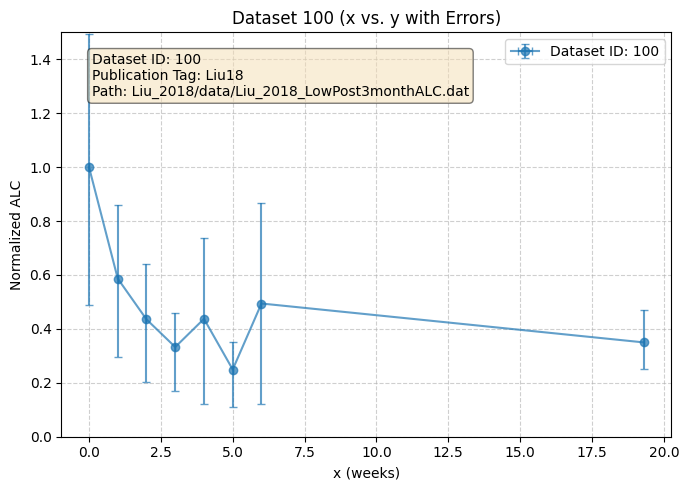

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Function to plot a specific dataset by Dataset ID with additional information
def plot_dataset_by_id(data, dataset_id):
    row = data[data['Dataset ID'] == dataset_id]
    
    if row.empty:
        print(f"No dataset found with Dataset ID: {dataset_id}")
        return
    
    row = row.iloc[0]  # Extract the first matching row
    
    # Convert data to numpy arrays
    x = np.array(row['x'])
    y = np.array(row['y'])
    x_low_err = np.array(row['x_low_err'])
    x_high_err = np.array(row['x_high_err'])
    y_low_err = np.array(row['y_low_err'])
    y_high_err = np.array(row['y_high_err'])
    
    # Check if y[0] is not zero to avoid division by zero
    if y[0] != 0:
        y_low_err = y_low_err / y[0]
        y_high_err = y_high_err / y[0]
        x_err = [x_low_err, x_high_err ]
        y_err = [y_low_err, y_high_err ]
        y = y / y[0]

        # Plot the dataset with error bars
        plt.figure(figsize=(7, 5))
        plt.errorbar(x, y, xerr=x_err, yerr=y_err,label=f"Dataset ID: {dataset_id}", fmt='o', capsize=3, alpha=0.7, linestyle='-')
        
        # Add dataset info on the plot
        publication_tag = row['Publication tag']
        relative_path = row['Relative path']
        plt.text(0.05, 0.95, f"Dataset ID: {dataset_id}\nPublication Tag: {publication_tag}\nPath: {relative_path}", 
                 transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
        
        # Customize the plot
        plt.title(f"Dataset {dataset_id} (x vs. y with Errors)")
        plt.xlabel("x (weeks)")
        plt.ylabel("Normalized ALC")
        #plt.xlim(0, 20)
        plt.ylim(0, 1.5)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"y[0] is zero for Dataset ID: {dataset_id}, cannot normalize y.")

# Example usage
plot_dataset_by_id(data, dataset_id=100)  # Replace with the desired Dataset ID


## This concludes the demo.

Feel free to explore the code further and perform your own analyses. Don't hesitate to experiment, modify, and extract additional insights from the dataset. 

Good luck and happy coding!